In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [2]:
#Preprocessing Tasks
#1. Loading the dataset into a Panda’s DataFrame (free points)
df = pd.read_csv('ruined_df.csv')
df.columns

Index(['age', 'income', 'math_final_grade', 'marital_status', 'num_children',
       'employment_status', 'credit_score', 'household_size', 'monthly_rent',
       'years_in_residence', 'car_ownership', 'internet_usage',
       'work_travel_distance', 'account_balance', 'loan_amount',
       'transaction_frequency'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    976 non-null    float64
 1   income                 967 non-null    float64
 2   math_final_grade       980 non-null    float64
 3   marital_status         966 non-null    object 
 4   num_children           981 non-null    float64
 5   employment_status      970 non-null    object 
 6   credit_score           981 non-null    float64
 7   household_size         982 non-null    float64
 8   monthly_rent           975 non-null    float64
 9   years_in_residence     964 non-null    float64
 10  car_ownership          981 non-null    object 
 11  internet_usage         969 non-null    object 
 12  work_travel_distance   971 non-null    float64
 13  account_balance        963 non-null    float64
 14  loan_amount            970 non-null    float64
 15  trans

In [4]:
# a. Replacing outliers with np.nan
# first detecting outliers: 
# indetify numerical featurs: 
numerical_features = df.select_dtypes( include= "number").columns
print(numerical_features)
print(len(numerical_features))

Index(['age', 'income', 'math_final_grade', 'num_children', 'credit_score',
       'household_size', 'monthly_rent', 'years_in_residence',
       'work_travel_distance', 'account_balance', 'loan_amount',
       'transaction_frequency'],
      dtype='object')
12


In [5]:
df[numerical_features].describe()# all of them have outliers 

,age,income,math_final_grade,num_children,credit_score,household_size,monthly_rent,years_in_residence,work_travel_distance,account_balance,loan_amount,transaction_frequency
count,9.760000e+02,9.670000e+02,9.800000e+02,9.810000e+02,9.810000e+02,9.820000e+02,9.750000e+02,9.640000e+02,9.710000e+02,9.630000e+02,9.700000e+02,9.790000e+02
mean,1.438111e+09,1.048217e+09,1.421102e+09,1.208724e+09,6.897324e+08,1.462429e+09,1.014192e+09,9.487158e+08,8.352170e+08,1.640539e+09,1.007628e+09,1.327487e+09
std,9.557176e+09,8.488050e+09,9.713194e+09,8.828433e+09,6.519218e+09,1.003872e+10,8.020758e+09,7.607764e+09,7.102839e+09,1.058463e+10,8.573250e+09,8.844839e+09
min,2.000000e+01,2.025100e+04,0.000000e+00,0.000000e+00,3.000000e+02,1.000000e+00,5.050000e+02,0.000000e+00,5.000000e+00,1.890000e+02,2.440000e+02,0.000000e+00
25%,3.400000e+01,6.569350e+04,2.600000e+01,1.000000e+00,4.380000e+02,3.000000e+00,1.588500e+03,7.000000e+00,2.100000e+01,2.410200e+04,2.478975e+04,8.800000e+01
50%,4.600000e+01,1.117370e+05,5.100000e+01,2.000000e+00,5.700000e+02,6.000000e+00,2.800000e+03,1.600000e+01,3.500000e+01,5.084300e+04,5.023350e+04,1.920000e+02
75%,5.800000e+01,1.526235e+05,7.600000e+01,3.000000e+00,7.210000e+02,8.000000e+00,3.969000e+03,2.300000e+01,4.900000e+01,7.896750e+04,7.711625e+04,2.760000e+02
max,9.342353e+10,9.433514e+10,9.696727e+10,9.898847e+10,8.694348e+10,9.735675e+10,9.596568e+10,8.969479e+10,9.689721e+10,9.946061e+10,9.914544e+10,9.567022e+10


In [6]:
col = 'age'
print(df[col].describe())
threshold = 90
minimum = int(df[col].min())
step = 5
# check the suitable maximum number of age to be a threshold: 
print( [sum(df[col] == var) for var in range(minimum, threshold,step )])
#get rid of the outliers:# remove the values greater than threshold
df[col] = df[col].apply(lambda x: np.nan if x > threshold 
                             else x )
df[col].describe()

count    9.760000e+02
mean     1.438111e+09
std      9.557176e+09
min      2.000000e+01
25%      3.400000e+01
50%      4.600000e+01
75%      5.800000e+01
max      9.342353e+10
Name: age, dtype: float64
[21, 18, 17, 18, 22, 14, 23, 22, 25, 12, 13, 0, 0, 0]


count    946.000000
mean      45.026427
std       14.497449
min       20.000000
25%       33.000000
50%       44.500000
75%       57.000000
max       70.000000
Name: age, dtype: float64

In [7]:
col = 'math_final_grade'
print(df[col].describe())
threshold = 100
minimum = int(df[col].min())
# remove the values greater than 100
df[col] = df[col].apply(lambda x: np.nan if x > threshold
                            else x )
df[col].describe()


count    9.800000e+02
mean     1.421102e+09
std      9.713194e+09
min      0.000000e+00
25%      2.600000e+01
50%      5.100000e+01
75%      7.600000e+01
max      9.696727e+10
Name: math_final_grade, dtype: float64


count    954.000000
mean      50.101677
std       28.757610
min        0.000000
25%       25.000000
50%       49.000000
75%       75.000000
max      100.000000
Name: math_final_grade, dtype: float64

In [8]:
col = 'num_children'
print(df[col].describe())
threshold = 10
minimum = int(df[col].min())
step = 1
# check the suitable maximum number of childern to be a threshold: 
print( [sum(df[col] == var) for var in range(minimum, threshold,step )])
#get rid of the outliers:# remove the values greater than threshold
df[col] = df[col].apply(lambda x: np.nan if x > threshold 
                             else x )
df[col].describe()

count    9.810000e+02
mean     1.208724e+09
std      8.828433e+09
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      9.898847e+10
Name: num_children, dtype: float64
[181, 194, 184, 195, 203, 0, 0, 0, 0, 0]


count    957.000000
mean       2.047022
std        1.418233
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        4.000000
Name: num_children, dtype: float64

In [ ]:
# # remove the values greater than 10
# df['num_children'] = df['num_children'].apply(lambda x: np.nan if x > 4
#                             else x )
# df['num_children'].describe()

In [9]:
col = 'years_in_residence'
print(df[col].describe())
threshold = 40
minimum = int(df[col].min())
step = 1
# check the suitable maximum number of childern to be a threshold: 
print( [sum(df[col] == var) for var in range(minimum, threshold,step )])
#get rid of the outliers:# remove the values greater than threshold
df[col] = df[col].apply(lambda x: np.nan if x > threshold 
                             else x )
df[col].describe()

count    9.640000e+02
mean     9.487158e+08
std      7.607764e+09
min      0.000000e+00
25%      7.000000e+00
50%      1.600000e+01
75%      2.300000e+01
max      8.969479e+10
Name: years_in_residence, dtype: float64
[29, 32, 37, 21, 33, 37, 32, 32, 27, 18, 30, 32, 21, 24, 24, 39, 38, 32, 39, 28, 33, 31, 33, 32, 30, 26, 25, 36, 37, 32, 23, 0, 0, 0, 0, 0, 0, 0, 0, 0]


count    943.000000
mean      15.081654
std        8.949772
min        0.000000
25%        7.000000
50%       16.000000
75%       23.000000
max       30.000000
Name: years_in_residence, dtype: float64

In [ ]:
plt.hist(df['credit_score'])
plt.show()

In [10]:
col = 'credit_score'
print(df[col].describe())
threshold = 2000
minimum = int(df[col].min())
step = 500
# select the maximum rage of monthly_rent
print([((df[col]> var) & (df[col]< var + step)).sum() for var in range(minimum, threshold ,step)])
#get rid of the outliers:
df[col] = df[col].apply(lambda x: np.nan if x > threshold 
                             else x )
df[col].describe()

count    9.810000e+02
mean     6.897324e+08
std      6.519218e+09
min      3.000000e+02
25%      4.380000e+02
50%      5.700000e+02
75%      7.210000e+02
max      8.694348e+10
Name: credit_score, dtype: float64
[np.int64(879), np.int64(84), np.int64(0), np.int64(0)]


count    966.000000
mean     569.378882
std      160.230376
min      300.000000
25%      435.000000
50%      563.500000
75%      715.000000
max      850.000000
Name: credit_score, dtype: float64

In [ ]:
# df['credit_score'] = df['credit_score'].apply(lambda x: np.nan if x > 2000
#                             else x )
# df['credit_score'].describe()

In [11]:
col = 'monthly_rent'
print(df[col].describe())
threshold = 7000
minimum = int(df[col].min())
step = 500
# select the maximum rage of monthly_rent
print([((df[col]> var) & (df[col]< var + step)).sum() for var in range(minimum, threshold ,step)])
#get rid of the outliers:
df[col] = df[col].apply(lambda x: np.nan if x > threshold 
                             else x )
df[col].describe()

count    9.750000e+02
mean     1.014192e+09
std      8.020758e+09
min      5.050000e+02
25%      1.588500e+03
50%      2.800000e+03
75%      3.969000e+03
max      9.596568e+10
Name: monthly_rent, dtype: float64
[np.int64(111), np.int64(113), np.int64(93), np.int64(102), np.int64(109), np.int64(101), np.int64(108), np.int64(104), np.int64(111), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


count     954.000000
mean     2749.426625
std      1318.388123
min       505.000000
25%      1564.000000
50%      2754.000000
75%      3924.250000
max      4996.000000
Name: monthly_rent, dtype: float64

In [12]:

col = 'income'
print(df[col].describe())
threshold = 500000
minimum = int(df[col].min())
step = 5000
# select the maximum range
print([((df[col]> var) & (df[col]< var + step)).sum() for var in range(minimum, threshold ,step)])
#get rid of the outliers:
df[col] = df[col].apply(lambda x: np.nan if x > threshold 
                             else x )
df[col].describe()

count    9.670000e+02
mean     1.048217e+09
std      8.488050e+09
min      2.025100e+04
25%      6.569350e+04
50%      1.117370e+05
75%      1.526235e+05
max      9.433514e+10
Name: income, dtype: float64
[np.int64(18), np.int64(31), np.int64(29), np.int64(23), np.int64(28), np.int64(28), np.int64(25), np.int64(30), np.int64(24), np.int64(30), np.int64(28), np.int64(26), np.int64(28), np.int64(25), np.int64(22), np.int64(33), np.int64(29), np.int64(20), np.int64(26), np.int64(34), np.int64(25), np.int64(32), np.int64(29), np.int64(28), np.int64(30), np.int64(26), np.int64(30), np.int64(18), np.int64(29), np.int64(22), np.int64(26), np.int64(22), np.int64(20), np.int64(22), np.int64(21), np.int64(26), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.i

count       946.000000
mean     108443.144820
std       50644.665306
min       20251.000000
25%       65125.500000
50%      108595.500000
75%      150215.500000
max      199553.000000
Name: income, dtype: float64

In [ ]:
# df['income'] = df['income'].apply(lambda x: np.nan if x > 500000 
#                             else x )
# df['income'].describe()

In [ ]:
plt.hist(df['account_balance'])
plt.show()

In [13]:
col = 'account_balance'
print(df[col].describe())
threshold = 200000
minimum = int(df[col].min())
step = 5000
# select the maximum range
print([((df[col]> var) & (df[col]< var + step)).sum() for var in range(minimum, threshold ,step)])
#get rid of the outliers:
df[col] = df[col].apply(lambda x: np.nan if x > threshold 
                             else x )
df[col].describe()

count    9.630000e+02
mean     1.640539e+09
std      1.058463e+10
min      1.890000e+02
25%      2.410200e+04
50%      5.084300e+04
75%      7.896750e+04
max      9.946061e+10
Name: account_balance, dtype: float64
[np.int64(49), np.int64(46), np.int64(46), np.int64(55), np.int64(55), np.int64(50), np.int64(51), np.int64(41), np.int64(39), np.int64(44), np.int64(44), np.int64(54), np.int64(28), np.int64(50), np.int64(44), np.int64(36), np.int64(51), np.int64(50), np.int64(44), np.int64(55), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


count      933.000000
mean     49560.263666
std      29523.680006
min        189.000000
25%      23637.000000
50%      48822.000000
75%      75566.000000
max      99918.000000
Name: account_balance, dtype: float64

In [14]:
col = 'household_size'
print(df[col].describe())
threshold = 20
minimum = int(df[col].min())
step = 2
# select the maximum range
print([((df[col]> var) & (df[col]< var + step)).sum() for var in range(minimum, threshold ,step)])
#get rid of the outliers:
df[col] = df[col].apply(lambda x: np.nan if x > threshold 
                             else x )
df[col].describe()

count    9.820000e+02
mean     1.462429e+09
std      1.003872e+10
min      1.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      8.000000e+00
max      9.735675e+10
Name: household_size, dtype: float64
[np.int64(80), np.int64(91), np.int64(99), np.int64(106), np.int64(90), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


count    955.000000
mean       5.684817
std        2.823629
min        1.000000
25%        3.000000
50%        6.000000
75%        8.000000
max       10.000000
Name: household_size, dtype: float64

In [15]:
col = 'work_travel_distance'
print(df[col].describe())
threshold = 500
minimum = int(df[col].min())
step = 50
# select the maximum range
print([((df[col]> var) & (df[col]< var + step)).sum() for var in range(minimum, threshold ,step)])
#get rid of the outliers:
df[col] = df[col].apply(lambda x: np.nan if x > threshold 
                             else x )
df[col].describe()

count    9.710000e+02
mean     8.352170e+08
std      7.102839e+09
min      5.000000e+00
25%      2.100000e+01
50%      3.500000e+01
75%      4.900000e+01
max      9.689721e+10
Name: work_travel_distance, dtype: float64
[np.int64(830), np.int64(99), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


count    952.000000
mean      33.884454
std       15.781609
min        5.000000
25%       21.000000
50%       34.000000
75%       48.000000
max       60.000000
Name: work_travel_distance, dtype: float64

In [16]:
col = 'loan_amount'
print(df[col].describe())
threshold = 200000
minimum = int(df[col].min())
step = 1000
# select the maximum range
print([((df[col]> var) & (df[col]< var + step)).sum() for var in range(minimum, threshold ,step)])
#get rid of the outliers:
df[col] = df[col].apply(lambda x: np.nan if x > threshold 
                             else x )
df[col].describe()

count    9.700000e+02
mean     1.007628e+09
std      8.573250e+09
min      2.440000e+02
25%      2.478975e+04
50%      5.023350e+04
75%      7.711625e+04
max      9.914544e+10
Name: loan_amount, dtype: float64
[np.int64(11), np.int64(10), np.int64(5), np.int64(5), np.int64(10), np.int64(12), np.int64(11), np.int64(9), np.int64(10), np.int64(13), np.int64(12), np.int64(7), np.int64(4), np.int64(10), np.int64(8), np.int64(6), np.int64(13), np.int64(13), np.int64(17), np.int64(10), np.int64(7), np.int64(15), np.int64(11), np.int64(7), np.int64(5), np.int64(13), np.int64(10), np.int64(11), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(8), np.int64(9), np.int64(9), np.int64(11), np.int64(12), np.int64(7), np.int64(13), np.int64(12), np.int64(8), np.int64(14), np.int64(12), np.int64(10), np.int64(11), np.int64(7), np.int64(10), np.int64(7), np.int64(9), np.int64(8), np.int64(10), np.int64(8), np.int64(12), np.int64(7), np.int64(8), np.int64(6), np.int64(10), np.int64(10), np.

count      951.000000
mean     49814.619348
std      28775.611638
min        244.000000
25%      24234.500000
50%      49114.000000
75%      75536.000000
max      99835.000000
Name: loan_amount, dtype: float64

In [17]:
col = 'transaction_frequency'
print(df[col].describe())
threshold = 1000
minimum = int(df[col].min())
step = 200
# select the maximum rage of monthly_rent
print([((df[col]> var) & (df[col]< var + step)).sum() for var in range(minimum, threshold ,step)])
#get rid of the outliers:
df[col] = df[col].apply(lambda x: np.nan if x > threshold 
                             else x )
df[col].describe()

count    9.790000e+02
mean     1.327487e+09
std      8.844839e+09
min      0.000000e+00
25%      8.800000e+01
50%      1.920000e+02
75%      2.760000e+02
max      9.567022e+10
Name: transaction_frequency, dtype: float64
[np.int64(504), np.int64(438), np.int64(0), np.int64(0), np.int64(0)]


count    950.000000
mean     181.086316
std      106.258591
min        0.000000
25%       86.000000
50%      185.000000
75%      267.000000
max      365.000000
Name: transaction_frequency, dtype: float64

In [18]:
df[numerical_features].describe()

,age,income,math_final_grade,num_children,credit_score,household_size,monthly_rent,years_in_residence,work_travel_distance,account_balance,loan_amount,transaction_frequency
count,946.000000,946.000000,954.000000,957.000000,966.000000,955.000000,954.000000,943.000000,952.000000,933.000000,951.000000,950.000000
mean,45.026427,108443.144820,50.101677,2.047022,569.378882,5.684817,2749.426625,15.081654,33.884454,49560.263666,49814.619348,181.086316
std,14.497449,50644.665306,28.757610,1.418233,160.230376,2.823629,1318.388123,8.949772,15.781609,29523.680006,28775.611638,106.258591
min,20.000000,20251.000000,0.000000,0.000000,300.000000,1.000000,505.000000,0.000000,5.000000,189.000000,244.000000,0.000000
25%,33.000000,65125.500000,25.000000,1.000000,435.000000,3.000000,1564.000000,7.000000,21.000000,23637.000000,24234.500000,86.000000
50%,44.500000,108595.500000,49.000000,2.000000,563.500000,6.000000,2754.000000,16.000000,34.000000,48822.000000,49114.000000,185.000000
75%,57.000000,150215.500000,75.000000,3.000000,715.000000,8.000000,3924.250000,23.000000,48.000000,75566.000000,75536.000000,267.000000
max,70.000000,199553.000000,100.000000,4.000000,850.000000,10.000000,4996.000000,30.000000,60.000000,99918.000000,99835.000000,365.000000


In [ ]:
# q1 = df['math_final_grade'].quantile(0.25)
# print(q1)
# q3 = df['math_final_grade'].quantile(0.75)
# print(q3)
# iqr = q3 - q1
# print(iqr)
# lower_bound = q1 - iqr *1.5
# print(lower_bound)
# upper_bound  = q3 + iqr *1.5
# print( upper_bound )
# outliers = (df['math_final_grade'] < lower_bound) | (df['math_final_grade'] > upper_bound)
# np.where(outliers, df['math_final_grade'], np.nan)
# #print(outliers)

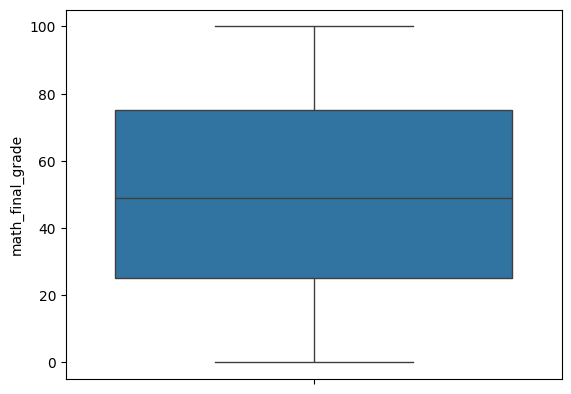

In [19]:
#detect outliers#
#visualize 
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(y=df['math_final_grade'])
plt.show()



In [ ]:
# b. Replace incorrect data types in columns with np.nan
# i. Remove integers from a column that is supposed to be strings
#ii. Remove strings from a column that is supposed to be ints/floats

In [20]:
mixeed_features = df.select_dtypes( exclude= "number").columns
print(mixeed_features)
print(len(mixeed_features))

Index(['marital_status', 'employment_status', 'car_ownership',
       'internet_usage'],
      dtype='object')
4


In [21]:
for col in list(df.columns):
    print(col, " : ", pd.api.types.infer_dtype(df[col]))

age  :  floating
income  :  floating
math_final_grade  :  floating
marital_status  :  string
num_children  :  floating
employment_status  :  string
credit_score  :  floating
household_size  :  floating
monthly_rent  :  floating
years_in_residence  :  floating
car_ownership  :  string
internet_usage  :  string
work_travel_distance  :  floating
account_balance  :  floating
loan_amount  :  floating
transaction_frequency  :  floating


In [22]:
# show the values insie each features: 
df['marital_status'].value_counts()

marital_status
Widowed        245
Single         241
Divorced       233
Married        233
20518829544      1
27260297804      1
51724880231      1
3178710047       1
34285343228      1
65306133638      1
30441274959      1
21089844805      1
73022414174      1
53964727244      1
41677635099      1
81951752676      1
89549071240      1
80456684750      1
Name: count, dtype: int64

In [23]:

for mixed_col  in mixeed_features:
    print(mixed_col , " : ",df[mixed_col].unique())
    print("******************************")

marital_status  :  ['Divorced' 'Single' 'Married' '20518829544' 'Widowed' nan '27260297804'
 '51724880231' '3178710047' '34285343228' '65306133638' '30441274959'
 '21089844805' '73022414174' '53964727244' '41677635099' '81951752676'
 '89549071240' '80456684750']
******************************
employment_status  :  ['Full-Time' 'Part-Time' 'Unemployed' nan '75575717800' '12697057726'
 '27916029545' '32492763032' '96059441273' '37145791483' '86526772238'
 '47782470418' '41549917989' '228326735' '22898718195' '41565224086'
 '93354894353' '51302079469' '94587166434' '6507493272' '27919671254'
 '8316784872' '96375379793' '68586365478' '73921503865' '45080022468'
 '49278997405' '38917136193' '91143566962' '3729287173' '81318489549'
 '94222694487' '22861209046' '63338646333']
******************************
car_ownership  :  ['No' 'Yes' nan '45553240042' '43624848327' '87613858308' '8377073710'
 '57701960304' '37630000650' '74777483724' '70496872813' '75997082105'
 '80023774031' '49151969926' 

In [24]:
#convert 'numbers' into np.nan
for mixed_col  in mixeed_features:
    df[mixed_col ] = df[mixed_col].apply(
        lambda x: np.nan if
        str(x).strip().isdigit()
        else x
    )

In [25]:
for mixed_col  in mixeed_features:
    print(df[mixed_col].unique())

['Divorced' 'Single' 'Married' nan 'Widowed']
['Full-Time' 'Part-Time' 'Unemployed' nan]
['No' 'Yes' nan]
['Low' 'High' 'Medium' nan]


In [26]:
# Replacing missing categorical values with the column’s most common value
# i. np.nan -> most common column value
from sklearn.impute import SimpleImputer
imputor = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
df[mixeed_features] = pd.DataFrame(imputor.fit_transform(df[mixeed_features]), columns = mixeed_features)


In [27]:
df[mixeed_features].isnull().sum()

marital_status       0
employment_status    0
car_ownership        0
internet_usage       0
dtype: int64

In [28]:
df[numerical_features].isnull().sum()

age                      54
income                   54
math_final_grade         46
num_children             43
credit_score             34
household_size           45
monthly_rent             46
years_in_residence       57
work_travel_distance     48
account_balance          67
loan_amount              49
transaction_frequency    50
dtype: int64

In [29]:
# c. Replacing missing numeric values with the column's mean value
# i. Np.nan -> some mean value
numerical_imputor = SimpleImputer(missing_values=np.nan, strategy='mean')
df[numerical_features] = pd.DataFrame(numerical_imputor.fit_transform(df[numerical_features]), columns = numerical_features)

In [30]:
df[numerical_features].isnull().sum()

age                      0
income                   0
math_final_grade         0
num_children             0
credit_score             0
household_size           0
monthly_rent             0
years_in_residence       0
work_travel_distance     0
account_balance          0
loan_amount              0
transaction_frequency    0
dtype: int64

In [31]:
mixeed_features[:2]

Index(['marital_status', 'employment_status'], dtype='object')

In [32]:
df[mixeed_features[:2]]

,marital_status,employment_status
0,Divorced,Full-Time
1,Single,Part-Time
2,Married,Full-Time
3,Married,Unemployed
4,Married,Part-Time
...,...,...
995,Married,Unemployed
996,Married,Full-Time
997,Divorced,Full-Time
998,Widowed,Full-Time


In [33]:
# 3. One Hot Encode the following columns:
# a. Marital Status
# b. Employment Status
encoded_features = pd.get_dummies(df[mixeed_features[:2]])
df = pd.concat([df, encoded_features], axis=1)
df.columns

Index(['age', 'income', 'math_final_grade', 'marital_status', 'num_children',
       'employment_status', 'credit_score', 'household_size', 'monthly_rent',
       'years_in_residence', 'car_ownership', 'internet_usage',
       'work_travel_distance', 'account_balance', 'loan_amount',
       'transaction_frequency', 'marital_status_Divorced',
       'marital_status_Married', 'marital_status_Single',
       'marital_status_Widowed', 'employment_status_Full-Time',
       'employment_status_Part-Time', 'employment_status_Unemployed'],
      dtype='object')

In [34]:
# c. Drop the categorical columns after you have OHE and appended the values
df.drop(columns=mixeed_features[:2], inplace=True )
df.columns
#drop# a. Marital Status
# b. Employment Status

Index(['age', 'income', 'math_final_grade', 'num_children', 'credit_score',
       'household_size', 'monthly_rent', 'years_in_residence', 'car_ownership',
       'internet_usage', 'work_travel_distance', 'account_balance',
       'loan_amount', 'transaction_frequency', 'marital_status_Divorced',
       'marital_status_Married', 'marital_status_Single',
       'marital_status_Widowed', 'employment_status_Full-Time',
       'employment_status_Part-Time', 'employment_status_Unemployed'],
      dtype='object')

In [35]:
# Binary Encode the following column:
# a. Car Ownership
print(df['car_ownership'].unique())
bin_map = {'Yes':1, 'No':0}
df['car_ownership'] = df['car_ownership'].apply(lambda x: bin_map[x])
print(df['car_ownership'].unique())

['No' 'Yes']
[0 1]


In [36]:
# Custom Encode the following column to fit the following set:
# a. Internet Usage {Low, Medium, High} -> {0, .5, 1} internet_usage
print(df['internet_usage'].unique())
bin_map = {'Low':0.0, 'Medium': 0.5, 'High':1}
df['internet_usage'] = df['internet_usage'].apply(lambda x: bin_map[x])
print(df['internet_usage'].unique())

['Low' 'High' 'Medium']
[0.  1.  0.5]


In [ ]:
print(sum(df['math_final_grade'] >=90))#A
print(((df['math_final_grade'] >=80 )&(df['math_final_grade'] <90)).sum())#B

107
74


In [ ]:
#Discretize the “final math grade” into binary bins
bins =   [0,   59,  69, 79,  89,100]
#[0, 59]=='F', (59,69]=='D', (69,79]=='C', (79,89]=='B', (89,100]=='A'
labels = ['F', 'D','C', 'B', 'A']
df['grade']= pd.cut(x = df['math_final_grade'], bins = bins, labels = labels, include_lowest = True)

In [46]:
df['grade'].value_counts()

grade
F    614
C    114
A    107
D     91
B     74
Name: count, dtype: int64

In [47]:
# a. You need to add 5 new columns to your dataframe
# i. math_grade_A, math_grade_B, math_grade_C, math_grade_D, math_grade_F
# b. If a sample has a math grade
encoded_features = pd.get_dummies(df['grade'],prefix="math_grade")
df = pd.concat([df, encoded_features], axis=1)
df.columns

Index(['age', 'income', 'math_final_grade', 'num_children', 'credit_score',
       'household_size', 'monthly_rent', 'years_in_residence', 'car_ownership',
       'internet_usage', 'work_travel_distance', 'account_balance',
       'loan_amount', 'transaction_frequency', 'marital_status_Divorced',
       'marital_status_Married', 'marital_status_Single',
       'marital_status_Widowed', 'employment_status_Full-Time',
       'employment_status_Part-Time', 'employment_status_Unemployed', 'grade',
       'math_grade_F', 'math_grade_D', 'math_grade_C', 'math_grade_B',
       'math_grade_A'],
      dtype='object')

In [48]:
df['math_grade_A'].value_counts()

math_grade_A
False    893
True     107
Name: count, dtype: int64

In [49]:
# c. DROP the final math grade column after you are done
df.drop(columns=['math_final_grade', 'grade'],inplace =True )
df.columns

Index(['age', 'income', 'num_children', 'credit_score', 'household_size',
       'monthly_rent', 'years_in_residence', 'car_ownership', 'internet_usage',
       'work_travel_distance', 'account_balance', 'loan_amount',
       'transaction_frequency', 'marital_status_Divorced',
       'marital_status_Married', 'marital_status_Single',
       'marital_status_Widowed', 'employment_status_Full-Time',
       'employment_status_Part-Time', 'employment_status_Unemployed',
       'math_grade_F', 'math_grade_D', 'math_grade_C', 'math_grade_B',
       'math_grade_A'],
      dtype='object')

In [54]:
numerical_features

Index(['age', 'income', 'math_final_grade', 'num_children', 'credit_score',
       'household_size', 'monthly_rent', 'years_in_residence',
       'work_travel_distance', 'account_balance', 'loan_amount',
       'transaction_frequency'],
      dtype='object')

In [56]:
#remove 'math_final_grade'
numerical_features = numerical_features.delete(2)
numerical_features

Index(['age', 'income', 'num_children', 'credit_score', 'household_size',
       'monthly_rent', 'years_in_residence', 'work_travel_distance',
       'account_balance', 'loan_amount', 'transaction_frequency'],
      dtype='object')

In [57]:
#7. Min-Max Scale your dataset
# exclude categorical values
from sklearn.preprocessing import MinMaxScaler
min_max =  MinMaxScaler(feature_range=(0, 1))
df[numerical_features] =  pd.DataFrame(min_max.fit_transform(df[numerical_features ]),columns=numerical_features)

In [61]:
df[numerical_features].describe()

,age,income,num_children,credit_score,household_size,monthly_rent,years_in_residence,work_travel_distance,account_balance,loan_amount,transaction_frequency
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.500529,0.491864,0.511755,0.489780,0.520535,0.499761,0.502722,0.525172,0.495054,0.497742,0.496127
std,0.282004,0.274715,0.346844,0.286328,0.306589,0.286724,0.289690,0.279960,0.285940,0.281763,0.283741
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.280000,0.263827,0.250000,0.252273,0.222222,0.245992,0.233333,0.304545,0.249927,0.256795,0.252055
50%,0.500529,0.491864,0.500000,0.489780,0.555556,0.499761,0.502722,0.525172,0.495054,0.497742,0.496127
75%,0.740000,0.707470,0.750000,0.741818,0.777778,0.746437,0.733333,0.763636,0.732894,0.744264,0.720548
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           1000 non-null   float64
 1   income                        1000 non-null   float64
 2   num_children                  1000 non-null   float64
 3   credit_score                  1000 non-null   float64
 4   household_size                1000 non-null   float64
 5   monthly_rent                  1000 non-null   float64
 6   years_in_residence            1000 non-null   float64
 7   car_ownership                 1000 non-null   int64  
 8   internet_usage                1000 non-null   float64
 9   work_travel_distance          1000 non-null   float64
 10  account_balance               1000 non-null   float64
 11  loan_amount                   1000 non-null   float64
 12  transaction_frequency         1000 non-null   float64
 13  mari